In [3]:
import numpy as np
import corner
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy
from scipy.stats import norm
import pandas as pd
import time


In [4]:
df_nld_talys=pd.read_csv("NLD_c0p0.csv")
df_nld_talys= df_nld_talys.drop(df_nld_talys.index[:2]) #drop weird dip at beginning

energy_nld_talys=df_nld_talys["Ex"].values # as numpy array
nld_talys=df_nld_talys["NLD"].values 

In [5]:
'''c = 0
p = 2.3

prev = 0
new_nld = []
new_err = []
np.random.seed()

shifted_energy = energy_nld_talys+p
sqrt_erg = np.sqrt(shifted_energy)
sqrt_erg[np.isnan(sqrt_erg)] = 0
exp = np.exp(c*sqrt_erg)

#nld_shift = np.interp(shifted_energy,energy_nld_talys,nld_talys)
for i in range(len(exp)):

    nld = exp[i]*nld_talys[i]
    noise = np.random.normal(1, 0.5)  # Gaussian noise with mean=1 and std=0.1
    new_y = nld * noise
    if new_y > prev:
        prev = new_y
    else:
        new_y = prev
    error = np.random.normal(loc=0.1, scale=nld * 0.1)  #make errorbar w/ Mean=0, std=10% of nld
    if error < 0:
        error = -error
    new_nld.append(new_y)
    new_err.append(error*(i+1)*.5) #scalars for "realism"
'''

'c = 0\np = 2.3\n\nprev = 0\nnew_nld = []\nnew_err = []\nnp.random.seed()\n\nshifted_energy = energy_nld_talys+p\nsqrt_erg = np.sqrt(shifted_energy)\nsqrt_erg[np.isnan(sqrt_erg)] = 0\nexp = np.exp(c*sqrt_erg)\n\n#nld_shift = np.interp(shifted_energy,energy_nld_talys,nld_talys)\nfor i in range(len(exp)):\n\n    nld = exp[i]*nld_talys[i]\n    noise = np.random.normal(1, 0.5)  # Gaussian noise with mean=1 and std=0.1\n    new_y = nld * noise\n    if new_y > prev:\n        prev = new_y\n    else:\n        new_y = prev\n    error = np.random.normal(loc=0.1, scale=nld * 0.1)  #make errorbar w/ Mean=0, std=10% of nld\n    if error < 0:\n        error = -error\n    new_nld.append(new_y)\n    new_err.append(error*(i+1)*.5) #scalars for "realism"\n'

In [6]:
a0 = 1
a1 = 2
x = np.linspace(0,10)

y = a0+a1*x
y_err = y/10

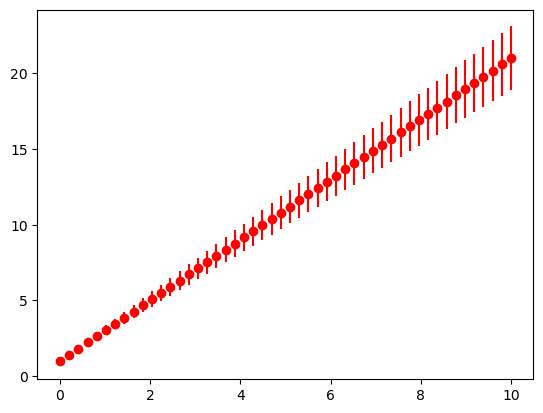

In [7]:
fig = plt.figure()

plt.errorbar(x,y,yerr=y_err,color="r",fmt='o')
#plt.errorbar(shifted_energy,new_nld,yerr=new_err,fmt='o',label=f'Gen. Data c = {c}, p ={p}')
#plt.yscale("log")

#plt.xlim(0, 20)
#plt.ylim(10**(0),10**(6))

#plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

In [8]:
def likely(param0,param1,data):
    likelihood_log_val=0
    model = param0+param1*np.linspace(0,10)
    sigmas = y_err
    for i in range(0,len(data)):
        likelihood_log_val=likelihood_log_val-1/2*((data[i] -model[i]) / sigmas[i])**2
        -np.log(2*np.pi*sigmas[i]**2)/2
    return likelihood_log_val,param0,param1

In [9]:
np.random.seed()
results = []
for i in range(0,10000):
    a0_guess = np.random.uniform(-3,3)
    a1_guess = np.random.uniform(-3,3)
    llv = likely(a0_guess,a1_guess,data=y)
    results.append(llv)

In [10]:
best_a0 = max(results)[1]
best_a1 = max(results)[2]
print(best_a0)

1.0598104889682025


In [11]:
y_guess= max(results)[1] + max(results)[2]*x

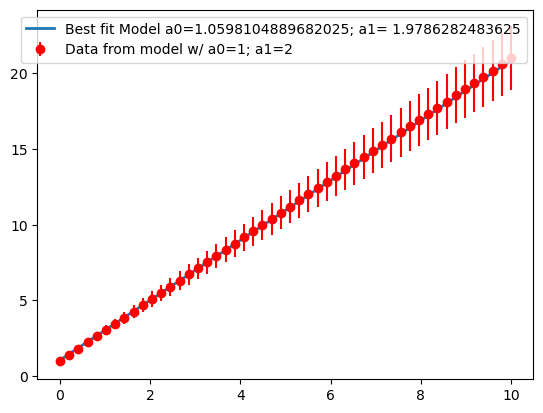

In [12]:
fig1 = plt.figure()


plt.errorbar(x,y,yerr=y_err,color="r",fmt='o',label = f'Data from model w/ a0={a0}; a1={a1}')
plt.plot(x,y_guess,label=f'Best fit Model a0={best_a0}; a1= {best_a1}',lw=2)
#plt.yscale("log")

#plt.xlim(0, 20)
#plt.ylim(10**(0),10**(6))

plt.legend()
plt.show()

Now to shift points around

In [14]:
np.random.seed(1034276)
# y_shift = y+np.random.normal(loc=1,scale=y_err)

y_shift = y+np.random.normal(loc=0,scale=y_err)

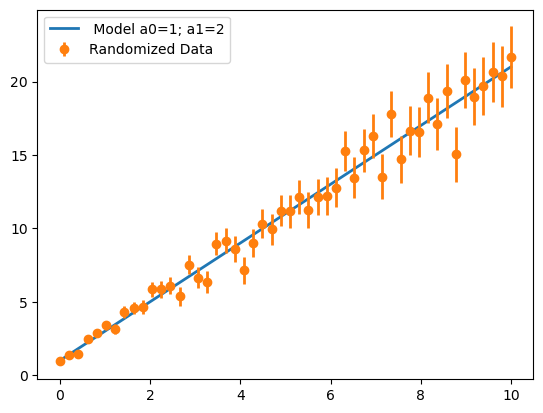

In [26]:
fig2 = plt.figure()
plt.plot(x,y,label=f' Model a0={a0}; a1={a1}',lw=2)
plt.errorbar(x,y_shift,yerr=y_err,fmt='o',label=f'Randomized Data ',lw=2)
plt.legend()
plt.show()

In [28]:
shift_results = []
for a in range(0,10000):
    a0_guess = np.random.uniform(-3,3)
    a1_guess = np.random.uniform(-3,3)
    llv = likely(a0_guess,a1_guess,data=y_shift)
    shift_results.append(llv)
shift_guess= max(shift_results)[1] + max(shift_results)[2]*x

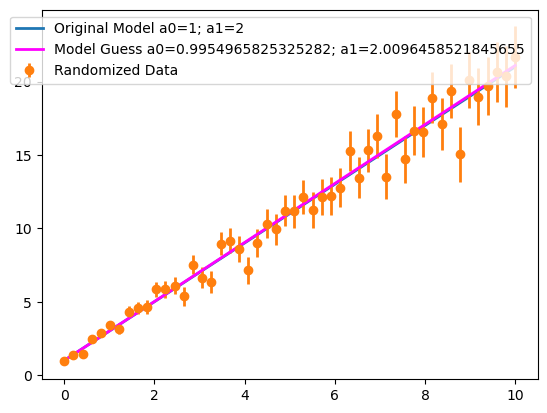

In [29]:
fig3 = plt.figure()

plt.plot(x,y,label=f'Original Model a0={a0}; a1={a1}',lw=2)
plt.errorbar(x,y_shift,yerr=y_err,fmt='o',label=f'Randomized Data ',lw=2)
plt.plot(x,shift_guess,label=f'Model Guess a0={max(shift_results)[1]}; a1={max(shift_results)[2]}',lw=2,color='magenta')
plt.legend()
plt.show()